# Predicting 30-Day Readmission Using Logistic Regression

**A teaching notebook for clinical risk prediction**

---

### Learning objectives
By the end of this notebook, you will be able to:
1. Recognize why **30-day readmission is a class-imbalanced problem** and why that changes which metrics matter.
2. Select and impute **clinically relevant predictors** (utilization history, chronic disease burden, discharge process variables, labs) using a leakage-safe, clinically-informed strategy.
3. Fit and evaluate a **Logistic Regression** classifier with **stratified k-fold cross-validation** and a **train / validation / test** design.
4. Compute and interpret **Accuracy, Sensitivity (Recall), Specificity, Precision, F1-score, and AUC-ROC**.
5. Reason about **which metric to prioritize clinically**, and how the **decision threshold** — not just the model — controls that trade-off.
6. Interpret logistic regression coefficients as **odds ratios**.

### About the dataset
The data is **synthetic**, generated *outside* this notebook by `generate_readmission_data.py`, which writes `data/readmission_clinical_data.csv`. As before, treat the CSV as "received from the hospital" — we only *read* it here.

The generator encodes well-established readmission-risk factors (prior utilization, heart failure/COPD/CKD, discharge disposition, follow-up scheduling) and injects **clinically plausible MAR missingness** — `ejection_fraction` and `bnp` are missing far more often in patients who never received a cardiac work-up — plus a class-**imbalanced** outcome (~20% readmitted), matching real 30-day readmission cohorts.

> 💡 **Teaching note:** Re-run `python generate_readmission_data.py` with a different `RANDOM_SEED` for a fresh cohort / exam variant.


## 0. Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, RocCurveDisplay,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the Data

Generated outside this notebook. If you haven't already:

```bash
python generate_readmission_data.py
```

This writes `data/readmission_clinical_data.csv`.


In [2]:
df = pd.read_csv("readmission_clinical_data.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (2000, 22)


,patient_id,age,sex,admission_type,icu_admission,length_of_stay_days,heart_failure,copd,ckd,diabetes,comorbidity_count,prior_admissions_12mo,discharge_disposition,polypharmacy,followup_scheduled,discharge_on_weekend,hemoglobin,creatinine,sodium,ejection_fraction,bnp,readmission_30d
0,R00001,66,Male,Elective,0,9.1,0,0,0,1,2,1,Home Health,8,1,0,10.60,1.50,140.3,52.2,NaN,0
1,R00002,70,Female,Urgent,0,3.9,0,0,0,0,1,2,Home,4,0,0,11.11,NaN,132.7,40.4,89.0,0
2,R00003,62,Male,Emergency,0,6.6,1,0,1,1,3,1,Home,11,1,0,8.36,1.06,136.2,67.6,217.0,0
3,R00004,53,Female,Emergency,0,8.2,1,1,0,0,3,1,Home,8,1,1,15.46,1.46,134.8,19.8,226.0,0
4,R00005,59,Female,Elective,0,5.3,0,1,0,0,2,3,SNF,8,1,0,12.93,1.67,132.6,NaN,220.0,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             2000 non-null   object 
 1   age                    2000 non-null   int64  
 2   sex                    2000 non-null   object 
 3   admission_type         2000 non-null   object 
 4   icu_admission          2000 non-null   int64  
 5   length_of_stay_days    2000 non-null   float64
 6   heart_failure          2000 non-null   int64  
 7   copd                   2000 non-null   int64  
 8   ckd                    2000 non-null   int64  
 9   diabetes               2000 non-null   int64  
 10  comorbidity_count      2000 non-null   int64  
 11  prior_admissions_12mo  2000 non-null   int64  
 12  discharge_disposition  2000 non-null   object 
 13  polypharmacy           2000 non-null   int64  
 14  followup_scheduled     2000 non-null   int64  
 15  disc

## 2. Exploratory Data Analysis

### 2.1 Class balance — the single most important fact about this dataset

30-day readmission is, in almost every real hospital cohort, an **imbalanced outcome**: most discharged patients are *not* readmitted within 30 days. This has a direct consequence for model evaluation: **a model that predicts "no readmission" for everyone can still score a high accuracy**, simply because the majority class dominates. Keep this firmly in mind through Section 8 (Metrics) and Section 9 (Which metric to emphasize).


30-day readmission prevalence: 23.2%
readmission_30d
0    1536
1     464
Name: count, dtype: int64


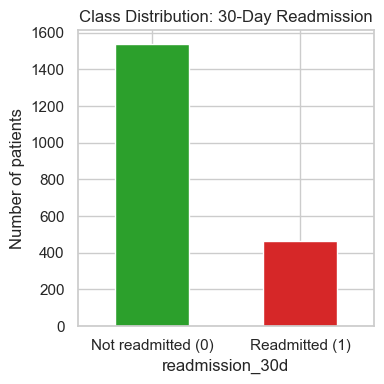


'Always predict NO readmission' baseline accuracy: 76.8%
^ Any model we build must clearly beat THIS, not just be 'high accuracy' in isolation.


In [4]:
prevalence = df["readmission_30d"].mean()
print(f"30-day readmission prevalence: {prevalence:.1%}")
print(df["readmission_30d"].value_counts())

fig, ax = plt.subplots(figsize=(4, 4))
df["readmission_30d"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#2ca02c", "#d62728"]
)
ax.set_xticklabels(["Not readmitted (0)", "Readmitted (1)"], rotation=0)
ax.set_title("Class Distribution: 30-Day Readmission")
ax.set_ylabel("Number of patients")
plt.tight_layout()
plt.show()

naive_baseline_accuracy = 1 - prevalence
print(f"\n'Always predict NO readmission' baseline accuracy: {naive_baseline_accuracy:.1%}")
print("^ Any model we build must clearly beat THIS, not just be 'high accuracy' in isolation.")


### 2.2 Univariate relationships with the outcome

A quick look at how a few known risk factors relate to readmission before modelling.


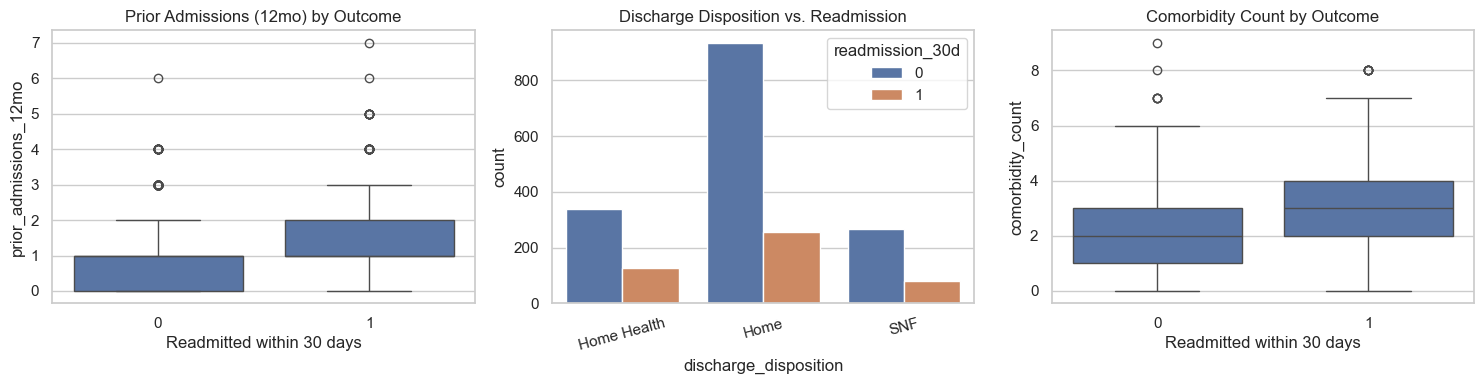

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x="readmission_30d", y="prior_admissions_12mo", data=df, ax=axes[0])
axes[0].set_title("Prior Admissions (12mo) by Outcome")
axes[0].set_xlabel("Readmitted within 30 days")

sns.countplot(x="discharge_disposition", hue="readmission_30d", data=df, ax=axes[1])
axes[1].set_title("Discharge Disposition vs. Readmission")
axes[1].tick_params(axis="x", rotation=15)

sns.boxplot(x="readmission_30d", y="comorbidity_count", data=df, ax=axes[2])
axes[2].set_title("Comorbidity Count by Outcome")
axes[2].set_xlabel("Readmitted within 30 days")

plt.tight_layout()
plt.show()


### 2.3 Missingness audit


In [6]:
missing_summary = (
    df.isna().sum().to_frame("n_missing")
    .assign(pct_missing=lambda d: (d["n_missing"] / len(df) * 100).round(1))
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)
missing_summary


,n_missing,pct_missing
ejection_fraction,589,29.4
bnp,512,25.6
creatinine,210,10.5
hemoglobin,69,3.4
sodium,65,3.2


In [7]:
check = df.assign(ef_missing=df["ejection_fraction"].isna())
print("Ejection fraction missingness rate by heart_failure status:")
print(check.groupby("heart_failure")["ef_missing"].mean().round(3))

print("\nCreatinine missingness rate by admission type:")
print(df.assign(creat_missing=df["creatinine"].isna()).groupby("admission_type")["creat_missing"].mean().round(3))


Ejection fraction missingness rate by heart_failure status:
heart_failure
0    0.350
1    0.113
Name: ef_missing, dtype: float64

Creatinine missingness rate by admission type:
admission_type
Elective     0.280
Emergency    0.038
Urgent       0.050
Name: creat_missing, dtype: float64


**Interpretation:** `ejection_fraction` (and `bnp`) are missing far less often in patients with a documented **heart failure** diagnosis — clinicians order an echo/BNP selectively when there's cardiac suspicion. This is **MAR**, not MCAR: dropping these rows would disproportionately remove non-heart-failure (generally lower-risk) patients, biasing the remaining sample toward sicker patients.


## 3. Train / Validation / Test Split — Stratified, and *before* Imputation/Scaling

Two important choices here:

1. **Split before imputing or scaling** (same leakage-avoidance rule as any pipeline): statistics used for imputation/scaling must come from the training set only.
2. **Stratify the split on the outcome (`readmission_30d`).** Because only ~1 in 5 patients is readmitted, a plain random split risks producing a validation or test set with a noticeably different (by chance) readmission rate than the training set — which would make our metrics harder to interpret and compare. `train_test_split(..., stratify=y)` keeps the class ratio approximately constant across all three splits.

We again use a 60% / 20% / 20% split.


In [8]:
categorical_cols = ["sex", "admission_type", "discharge_disposition"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

feature_cols = [c for c in df_encoded.columns if c not in ["patient_id", "readmission_30d"]]
target_col = "readmission_30d"

X = df_encoded[feature_cols].copy()
y = df_encoded[target_col].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_full
)

print(f"Train:      {len(X_train)} patients | readmit rate {y_train.mean():.1%}")
print(f"Validation: {len(X_val)} patients | readmit rate {y_val.mean():.1%}")
print(f"Test:       {len(X_test)} patients | readmit rate {y_test.mean():.1%}")


Train:      1200 patients | readmit rate 23.2%
Validation: 400 patients | readmit rate 23.2%
Test:       400 patients | readmit rate 23.2%


## 4. Clinically-Relevant Missing Value Imputation

Same two-step, clinically motivated strategy as before:

1. **Flag before you fill** — a missing `ejection_fraction`/`bnp` is itself informative (no cardiac work-up was ordered, which usually means the clinical team judged cardiac involvement unlikely) — so we preserve that signal as a binary indicator.
2. **Impute with the training set's median, stratified by a clinically meaningful group** — for `ejection_fraction`/`bnp` we stratify by `heart_failure` status (a heart-failure patient's "typical" EF is very different from a non-HF patient's); for `creatinine` we stratify by `admission_type`, as before.

All statistics are learned from `X_train` only.


In [9]:
cardiac_cols = ["ejection_fraction", "bnp"]
other_lab_cols = ["hemoglobin", "creatinine", "sodium"]
all_lab_cols = cardiac_cols + other_lab_cols

for col in all_lab_cols:
    for split_df in (X_train, X_val, X_test):
        split_df[f"{col}_was_missing"] = split_df[col].isna().astype(int)

hf_train = df.loc[X_train.index, "heart_failure"]
hf_val = df.loc[X_val.index, "heart_failure"]
hf_test = df.loc[X_test.index, "heart_failure"]

admtype_train = df.loc[X_train.index, "admission_type"]
admtype_val = df.loc[X_val.index, "admission_type"]
admtype_test = df.loc[X_test.index, "admission_type"]

overall_medians, hf_group_medians, admtype_group_medians = {}, {}, {}
for col in cardiac_cols:
    overall_medians[col] = X_train[col].median()
    hf_group_medians[col] = X_train.groupby(hf_train)[col].median()
for col in ["creatinine"]:
    overall_medians[col] = X_train[col].median()
    admtype_group_medians[col] = X_train.groupby(admtype_train)[col].median()
for col in ["hemoglobin", "sodium"]:
    overall_medians[col] = X_train[col].median()

def impute(frame, hf_series, admtype_series):
    frame = frame.copy()
    for col in cardiac_cols:
        fill = hf_series.map(hf_group_medians[col]).fillna(overall_medians[col])
        frame[col] = frame[col].fillna(fill)
    for col in ["creatinine"]:
        fill = admtype_series.map(admtype_group_medians[col]).fillna(overall_medians[col])
        frame[col] = frame[col].fillna(fill)
    for col in ["hemoglobin", "sodium"]:
        frame[col] = frame[col].fillna(overall_medians[col])
    return frame

X_train = impute(X_train, hf_train, admtype_train)
X_val = impute(X_val, hf_val, admtype_val)
X_test = impute(X_test, hf_test, admtype_test)

print("Remaining missing values after imputation:")
print(f"  Train: {X_train[all_lab_cols].isna().sum().sum()}")
print(f"  Val:   {X_val[all_lab_cols].isna().sum().sum()}")
print(f"  Test:  {X_test[all_lab_cols].isna().sum().sum()}")


Remaining missing values after imputation:
  Train: 0
  Val:   0
  Test:  0


## 5. Feature Engineering

Derived, clinically grounded features (built after imputation, applied identically to all splits):

| Feature | Clinical rationale |
|---|---|
| `high_utilizer_flag` | ≥ 2 admissions in the prior 12 months — a well-established high-risk marker used in real readmission programs (c.f. the "H" and prior-utilization components of the LACE/HOSPITAL scores). |
| `polypharmacy_flag` | ≥ 10 discharge medications — associated with medication errors and adverse events post-discharge. |
| `reduced_ef_flag` | Ejection fraction < 40% — standard threshold for heart failure with reduced ejection fraction (HFrEF), a high-risk phenotype. |
| `elevated_bnp_flag` | BNP > 400 pg/mL — commonly used clinical cut-off suggesting decompensated heart failure. |
| `no_followup_flag` | No follow-up appointment scheduled at discharge — a modifiable, actionable risk factor (unlike age or comorbidities). |
| `chronic_disease_burden` | Sum of heart failure + COPD + CKD + diabetes flags. |


In [10]:
def engineer_features(frame):
    frame = frame.copy()
    frame["high_utilizer_flag"] = (frame["prior_admissions_12mo"] >= 2).astype(int)
    frame["polypharmacy_flag"] = (frame["polypharmacy"] >= 10).astype(int)
    frame["reduced_ef_flag"] = (frame["ejection_fraction"] < 40).astype(int)
    frame["elevated_bnp_flag"] = (frame["bnp"] > 400).astype(int)
    frame["no_followup_flag"] = (frame["followup_scheduled"] == 0).astype(int)
    frame["chronic_disease_burden"] = (
        frame["heart_failure"] + frame["copd"] + frame["ckd"] + frame["diabetes"]
    )
    return frame

X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
X_test = engineer_features(X_test)

new_cols = [
    "high_utilizer_flag", "polypharmacy_flag", "reduced_ef_flag",
    "elevated_bnp_flag", "no_followup_flag", "chronic_disease_burden",
]
X_train[new_cols].mean().round(3).rename("proportion / mean in training set")


high_utilizer_flag        0.254
polypharmacy_flag         0.320
reduced_ef_flag           0.241
elevated_bnp_flag         0.098
no_followup_flag          0.366
chronic_disease_burden    0.933
Name: proportion / mean in training set, dtype: float64

## 6. Feature Scaling

Logistic Regression is fit by gradient-based optimization internally, and its regularization (on by default in scikit-learn) penalizes coefficients on a scale that depends on the feature's units — so scaling continuous predictors is more than cosmetic here (unlike plain OLS linear regression). We fit `StandardScaler` on the training set only.


In [11]:
binary_like_cols = [c for c in X_train.columns if X_train[c].dropna().isin([0, 1]).all()]
continuous_cols = [c for c in X_train.columns if c not in binary_like_cols]
print(f"Scaling {len(continuous_cols)} continuous features; leaving {len(binary_like_cols)} binary/flag features unscaled.")

scaler = StandardScaler()
scaler.fit(X_train[continuous_cols])

def scale_continuous(frame):
    frame = frame.copy()
    frame[continuous_cols] = scaler.transform(frame[continuous_cols])
    return frame

X_train_scaled = scale_continuous(X_train)
X_val_scaled = scale_continuous(X_val)
X_test_scaled = scale_continuous(X_test)
X_train_scaled.head()


Scaling 11 continuous features; leaving 22 binary/flag features unscaled.


,age,icu_admission,length_of_stay_days,heart_failure,copd,ckd,diabetes,comorbidity_count,prior_admissions_12mo,polypharmacy,followup_scheduled,discharge_on_weekend,hemoglobin,creatinine,sodium,ejection_fraction,bnp,sex_Male,admission_type_Emergency,admission_type_Urgent,discharge_disposition_Home Health,discharge_disposition_SNF,ejection_fraction_was_missing,bnp_was_missing,hemoglobin_was_missing,creatinine_was_missing,sodium_was_missing,high_utilizer_flag,polypharmacy_flag,reduced_ef_flag,elevated_bnp_flag,no_followup_flag,chronic_disease_burden
12,0.175556,0,-0.475838,0,0,0,1,-0.386775,-0.893773,-1.522431,1,1,1.196640,-1.081645,0.295422,-1.201433,-0.335966,False,False,False,True,False,0,0,0,0,0,0,0,1,0,0,0.080128
1036,0.175556,0,-1.445288,1,0,0,0,-0.386775,-0.893773,-0.333806,1,0,0.768375,-0.008545,0.801752,-0.982353,4.418419,True,False,True,False,True,0,0,0,0,0,0,0,1,1,0,0.080128
94,0.036548,0,-0.605098,0,0,0,0,-0.386775,-0.893773,-0.036649,1,0,1.400576,-0.346373,-1.426099,0.441668,-0.393805,True,True,False,False,False,0,0,0,0,0,0,0,0,0,0,-1.121796
49,2.121678,0,0.881391,1,1,0,1,2.239137,0.024487,2.043445,1,0,-0.047368,-0.266884,-1.248883,1.537069,2.953159,True,True,False,False,False,0,0,0,0,0,0,1,0,1,0,2.483978
695,2.121678,0,-1.251398,0,0,1,0,-1.043253,0.024487,-1.522431,1,0,1.492347,-0.088034,-0.514705,0.128697,-0.598170,False,False,True,True,False,0,0,0,0,0,0,0,0,0,0,0.080128


## 7. Stratified K-Fold Cross-Validation

We use `StratifiedKFold` (not plain `KFold`) so that **every fold preserves the ~20% readmission prevalence** — with plain random folds on an imbalanced outcome, some folds could end up with very few positive cases by chance, making per-fold metrics noisy and hard to compare.

We also pass `class_weight="balanced"` to `LogisticRegression`, which re-weights the loss function to counteract class imbalance during training (it does **not** change the data, only how much each class "counts" when fitting coefficients). We evaluate CV performance using **ROC-AUC**, which — unlike accuracy — is insensitive to the classification threshold and remains meaningful under class imbalance.


In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
logreg_cv = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)

cv_auc_scores = cross_val_score(logreg_cv, X_train_scaled, y_train, cv=skf, scoring="roc_auc")

cv_results = pd.DataFrame({"fold": range(1, 6), "ROC_AUC": cv_auc_scores.round(3)})
cv_results


,fold,ROC_AUC
0,1,0.744
1,2,0.749
2,3,0.746
3,4,0.737
4,5,0.771


In [13]:
print(f"Mean CV ROC-AUC: {cv_auc_scores.mean():.3f} (± {cv_auc_scores.std():.3f})")


Mean CV ROC-AUC: 0.749 (± 0.011)


**Interpretation:** ROC-AUC around 0.75-0.85 here indicates the model has **good discriminative ability** — i.e., if we picked one randomly readmitted patient and one randomly non-readmitted patient, the model assigns the readmitted patient a higher predicted risk most of the time. A low fold-to-fold standard deviation indicates this discrimination is **stable** across different patient subsamples.


## 7B. Alternative: Addressing Class Imbalance with SMOTE

`class_weight="balanced"` (Section 7) handles imbalance by **re-weighting the loss function** — the training data itself is untouched. An alternative, very commonly taught approach is **SMOTE (Synthetic Minority Oversampling Technique)**, which instead **rebalances the training data** by synthesizing new minority-class (readmitted) samples.

### 7B.1 How SMOTE works

For each minority-class (readmitted) patient, SMOTE:
1. Finds its *k* nearest minority-class neighbors in feature space (default *k*=5).
2. Picks one neighbor at random and generates a **synthetic** patient at a random point along the line segment connecting the two — i.e., a plausible "interpolated" patient, not a duplicate.
3. Repeats until the minority class reaches the desired proportion (here, a 1:1 balance with the majority class).

This is more sophisticated than naive random oversampling (which just duplicates existing minority rows and can encourage overfitting to those exact points), because SMOTE creates *new*, interpolated feature combinations.

> ⚠️ **The single most important rule for using SMOTE correctly: fit and apply it ONLY to the training data — never to validation or test data, and never *before* cross-validation splitting.** If synthetic points are generated before splitting (or before each CV fold), information from would-be validation/test patients leaks into the neighbors used to build synthetic training points, inflating performance estimates. We use `imblearn.pipeline.Pipeline` (not plain scikit-learn `Pipeline`) precisely because it applies SMOTE **inside** each cross-validation fold — fitting it on that fold's training portion only — and never touches the held-out fold at all.


In [14]:
print(f"Training set class counts BEFORE SMOTE:\n{y_train.value_counts()}")

smote_preview = SMOTE(random_state=RANDOM_STATE)
X_train_smote_preview, y_train_smote_preview = smote_preview.fit_resample(X_train_scaled, y_train)

print(f"\nTraining set class counts AFTER SMOTE (illustration only):\n{y_train_smote_preview.value_counts()}")
print(f"\nOriginal training rows: {len(X_train_scaled)}  ->  After SMOTE: {len(X_train_smote_preview)}")
print("(This resampled set is shown for illustration; the CV comparison below applies SMOTE correctly, inside each fold.)")


Training set class counts BEFORE SMOTE:
readmission_30d
0    922
1    278
Name: count, dtype: int64

Training set class counts AFTER SMOTE (illustration only):
readmission_30d
0    922
1    922
Name: count, dtype: int64

Original training rows: 1200  ->  After SMOTE: 1844
(This resampled set is shown for illustration; the CV comparison below applies SMOTE correctly, inside each fold.)


### 7B.2 Comparing `class_weight="balanced"` vs. SMOTE vs. no adjustment, fairly

We compare three strategies using the **same** `StratifiedKFold` splits, so the comparison isn't confounded by which patients happen to land in which fold. For SMOTE, we wrap `SMOTE` + `LogisticRegression` in an `imblearn` `Pipeline` and pass the *whole pipeline* to `cross_val_score` — this guarantees SMOTE is refit on only the training portion of every fold.


In [15]:
logreg_plain = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg_balanced = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
smote_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

strategies = {
    "No adjustment": logreg_plain,
    "class_weight='balanced'": logreg_balanced,
    "SMOTE": smote_pipeline,
}

comparison_rows = []
for name, estimator in strategies.items():
    auc_scores = cross_val_score(estimator, X_train_scaled, y_train, cv=skf, scoring="roc_auc")
    comparison_rows.append({
        "strategy": name,
        "mean_CV_ROC_AUC": round(auc_scores.mean(), 3),
        "std_CV_ROC_AUC": round(auc_scores.std(), 3),
    })

imbalance_comparison = pd.DataFrame(comparison_rows)
imbalance_comparison


,strategy,mean_CV_ROC_AUC,std_CV_ROC_AUC
0,No adjustment,0.752,0.015
1,class_weight='balanced',0.749,0.011
2,SMOTE,0.724,0.010


**Interpretation:** All three strategies typically land within a similar ROC-AUC range for a simple linear model like logistic regression — SMOTE and class-weighting are both just ways of telling the model "care more about the minority class during fitting," and neither invents genuinely new information the way, say, collecting more real readmitted-patient data would. Where they *can* differ more noticeably is in the resulting **default-threshold (0.5) behaviour**: both SMOTE and `class_weight="balanced"` tend to push the default 0.5 threshold to behave more like a "sensitivity-favoring" threshold, compared to fitting on the raw imbalanced data with no adjustment at all — but as Section 9 shows, explicitly choosing a threshold (rather than relying on either technique to do it implicitly) gives you direct, transparent control over the sensitivity/specificity trade-off regardless of which training-time strategy you use.

We continue with `class_weight="balanced"` as our primary final model (Section 8 onward) since it is simpler, requires no synthetic data generation, and is easier to explain to a clinical audience — but we bring the SMOTE-trained pipeline back for a direct, held-out test-set comparison in Section 10.


## 8. Fit the Final Model and Check on the Validation Set


In [16]:
final_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
final_model.fit(X_train_scaled, y_train)

val_proba = final_model.predict_proba(X_val_scaled)[:, 1]
val_auc = roc_auc_score(y_val, val_proba)
print(f"Validation ROC-AUC: {val_auc:.3f}")


Validation ROC-AUC: 0.742


### 8.1 The ROC curve, and what "AUC" actually measures

The **ROC (Receiver Operating Characteristic) curve** plots **Sensitivity (True Positive Rate)** against **1 − Specificity (False Positive Rate)** as we sweep the classification threshold from 0 to 1. The **Area Under the Curve (AUC-ROC)** summarizes this into a single number:

- **AUC = 1.0** → perfect discrimination (readmitted patients always ranked higher risk than non-readmitted).
- **AUC = 0.5** → no better than random guessing (the diagonal line).
- **AUC ≈ 0.7-0.8** → "acceptable to good" discrimination, a common range for real clinical readmission models (e.g., LACE index reports are typically in this range).

Crucially, **AUC-ROC is threshold-independent** — it evaluates the model's *ranking* ability across all possible thresholds, which is exactly why we use it for model selection/CV (Section 7) *before* committing to a single operating threshold (Section 9).


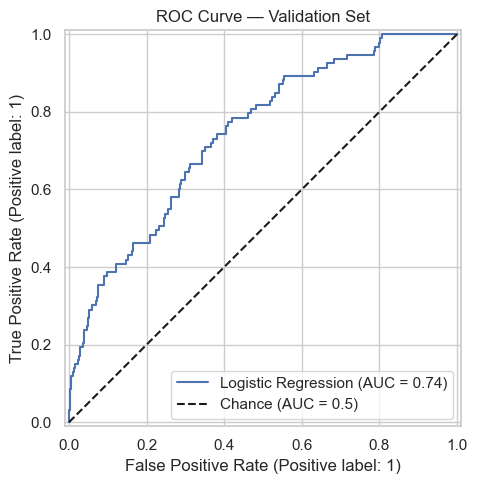

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_val, val_proba, ax=ax, name="Logistic Regression")
ax.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.5)")
ax.set_title("ROC Curve — Validation Set")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Choosing a Decision Threshold — and Which Metric to Emphasize Clinically

By default, `predict()` uses a **0.5 probability threshold**. That default is a statistical convention, **not a clinical one** — for 30-day readmission, it is usually the wrong choice, and picking the right threshold is arguably more consequential than the choice of algorithm.

### 9.1 The clinical asymmetry

Consider what each error type actually costs:

| | Predicted: will NOT readmit | Predicted: WILL readmit |
|---|---|---|
| **Actually readmitted** | **False Negative** — a high-risk patient is missed; no extra discharge support, transitional care call, or early follow-up is arranged → potentially preventable readmission occurs | True Positive — patient correctly flagged; gets extra support |
| **Actually not readmitted** | True Negative | **False Positive** — patient gets an extra phone call / earlier follow-up visit / pharmacist medication review they didn't strictly need |

The cost of a **False Negative** (missing a patient who will bounce back — potential harm, and a costly unplanned readmission that CMS/payers may penalize) is usually **much higher** than the cost of a **False Positive** (some "wasted" but low-risk, low-cost outreach — a phone call, a slightly earlier follow-up visit).

> 🩺 **This asymmetry is why, for 30-day readmission risk stratification, clinical teams typically prioritize SENSITIVITY (Recall) over Specificity or even overall Accuracy** — we would rather over-flag some low-risk patients for a cheap intervention (phone call, pharmacist review) than under-flag a high-risk patient who then bounces back. This is the same logic used in screening tests generally (e.g., cancer screening favors sensitivity; a confirmatory/diagnostic test downstream can then improve specificity).

**Important caveat:** "prioritize sensitivity" does **not** mean "maximize sensitivity at all costs" (e.g., flagging 100% of patients gives 100% sensitivity but is clinically useless — it wastes the entire care-management team's capacity). The real-world decision is: **given a fixed number of care-transition/outreach slots the hospital can actually staff, what threshold flags roughly that many patients while capturing as many of the true readmissions as possible?** This is why we look at the **whole ROC curve and Precision-Recall curve** below, not just one metric.

### 9.2 Why NOT accuracy alone

Recall our naive baseline from Section 2.1: simply predicting "no readmission" for every patient already achieves ~80% accuracy on this cohort, while being clinically useless (0% sensitivity — it would catch **zero** true readmissions). **Accuracy is a poor headline metric whenever the outcome is imbalanced**, exactly the situation we're in.

### 9.3 Role of F1-score

F1 (the harmonic mean of Precision and Recall) is useful as a **single balanced summary** when both false positives and false negatives matter and you want one number — but it implicitly weights them equally, which, per the argument above, usually is **not** the right clinical weighting for readmission. We report F1 for completeness/comparability with other studies, but recommend inspecting **sensitivity, specificity, and the ROC curve together** rather than optimizing F1 in isolation.


In [18]:
thresholds_to_try = np.arange(0.1, 0.91, 0.05)
threshold_rows = []
for t in thresholds_to_try:
    preds = (val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    threshold_rows.append({
        "threshold": round(t, 2),
        "sensitivity_recall": round(sensitivity, 3),
        "specificity": round(specificity, 3),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "f1": round(f1_score(y_val, preds, zero_division=0), 3),
        "accuracy": round(accuracy_score(y_val, preds), 3),
        "n_flagged": int(preds.sum()),
    })

threshold_table = pd.DataFrame(threshold_rows)
threshold_table


,threshold,sensitivity_recall,specificity,precision,f1,accuracy,n_flagged
0,0.10,1.000,0.059,0.243,0.392,0.278,382
1,0.15,1.000,0.134,0.259,0.412,0.335,359
2,0.20,0.978,0.202,0.271,0.424,0.383,336
3,0.25,0.935,0.303,0.289,0.442,0.450,301
4,0.30,0.892,0.391,0.307,0.457,0.507,270
5,0.35,0.839,0.472,0.325,0.468,0.557,240
6,0.40,0.785,0.577,0.360,0.493,0.625,203
7,0.45,0.720,0.635,0.374,0.493,0.655,179
8,0.50,0.645,0.691,0.387,0.484,0.680,155
9,0.55,0.538,0.749,0.394,0.455,0.700,127


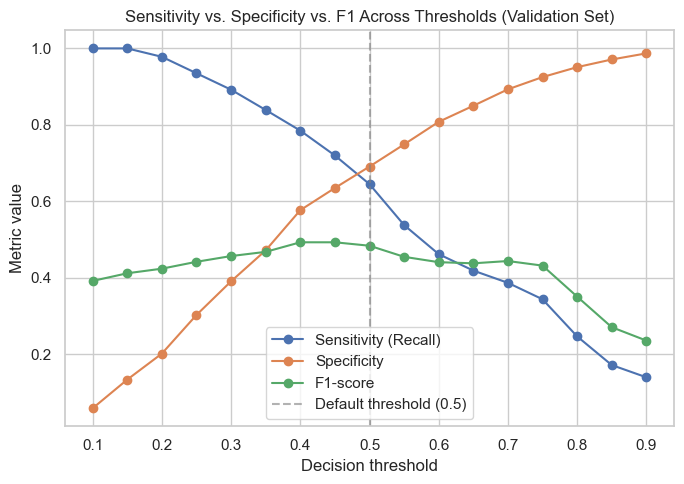

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(threshold_table["threshold"], threshold_table["sensitivity_recall"], marker="o", label="Sensitivity (Recall)")
ax.plot(threshold_table["threshold"], threshold_table["specificity"], marker="o", label="Specificity")
ax.plot(threshold_table["threshold"], threshold_table["f1"], marker="o", label="F1-score")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="Default threshold (0.5)")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.set_title("Sensitivity vs. Specificity vs. F1 Across Thresholds (Validation Set)")
ax.legend()
plt.tight_layout()
plt.show()


**Reading this chart:** as the threshold rises, specificity climbs but sensitivity falls — the fundamental trade-off. Given the clinical argument in 9.1, a hospital readmission-prevention program would typically pick a threshold **below 0.5** (flagging more patients, accepting lower specificity) to keep sensitivity high, **as long as** the resulting number of flagged patients (`n_flagged`) is within the care-management team's actual outreach capacity. We select a threshold below for the final test-set evaluation, using **Youden's J statistic** (sensitivity + specificity − 1, maximized) as one principled, capacity-agnostic starting point — then note how a capacity constraint would further adjust it.


In [20]:
fpr, tpr, roc_thresholds = roc_curve(y_val, val_proba)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
youden_threshold = roc_thresholds[best_idx]

print(f"Youden's J-optimal threshold: {youden_threshold:.3f}")
print(f"  -> Sensitivity at this threshold: {tpr[best_idx]:.3f}")
print(f"  -> Specificity at this threshold: {1 - fpr[best_idx]:.3f}")


Youden's J-optimal threshold: 0.406
  -> Sensitivity at this threshold: 0.785
  -> Specificity at this threshold: 0.580


## 10. Final, Held-Out Test Set Evaluation

We now apply the model **once** to the test set — untouched until now — using the Youden-optimal threshold identified on the validation set (never re-derive the threshold from the test set itself, for the same leakage-discipline reasons discussed in the LOS notebook).


In [21]:
test_proba = final_model.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

final_threshold = youden_threshold
test_preds = (test_proba >= final_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = precision_score(y_test, test_preds, zero_division=0)
f1 = f1_score(y_test, test_preds, zero_division=0)
accuracy = accuracy_score(y_test, test_preds)

print("FINAL TEST SET PERFORMANCE")
print("=" * 40)
print(f"Decision threshold used:  {final_threshold:.3f}  (Youden's J, chosen on validation set)")
print(f"ROC-AUC (threshold-free): {test_auc:.3f}")
print(f"Accuracy:                 {accuracy:.3f}")
print(f"Sensitivity (Recall):     {sensitivity:.3f}")
print(f"Specificity:              {specificity:.3f}")
print(f"Precision:                {precision:.3f}")
print(f"F1-score:                 {f1:.3f}")


FINAL TEST SET PERFORMANCE
Decision threshold used:  0.406  (Youden's J, chosen on validation set)
ROC-AUC (threshold-free): 0.808
Accuracy:                 0.672
Sensitivity (Recall):     0.817
Specificity:              0.629
Precision:                0.400
F1-score:                 0.537


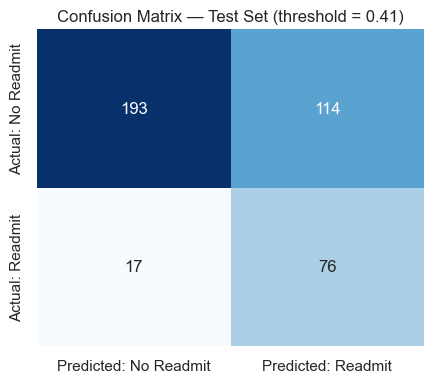

              precision    recall  f1-score   support

  No Readmit       0.92      0.63      0.75       307
     Readmit       0.40      0.82      0.54        93

    accuracy                           0.67       400
   macro avg       0.66      0.72      0.64       400
weighted avg       0.80      0.67      0.70       400



In [22]:
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
    xticklabels=["Predicted: No Readmit", "Predicted: Readmit"],
    yticklabels=["Actual: No Readmit", "Actual: Readmit"],
)
ax.set_title(f"Confusion Matrix — Test Set (threshold = {final_threshold:.2f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_preds, target_names=["No Readmit", "Readmit"]))


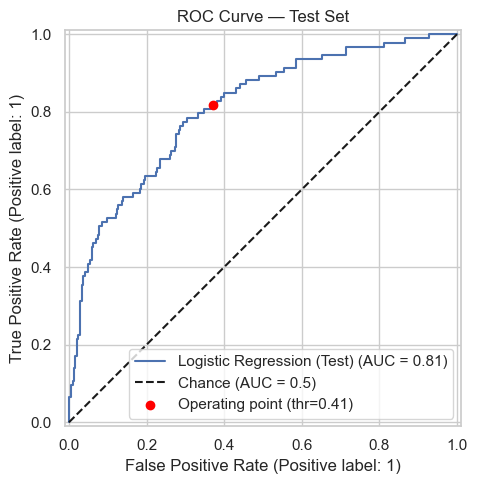

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_test, test_proba, ax=ax, name="Logistic Regression (Test)")
ax.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.5)")
ax.scatter(
    1 - specificity, sensitivity, color="red", zorder=5,
    label=f"Operating point (thr={final_threshold:.2f})"
)
ax.set_title("ROC Curve — Test Set")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation of the test-set result:** Test ROC-AUC close to the CV/validation AUC (Sections 7-8) indicates the model generalizes. At the chosen threshold, **sensitivity should be noticeably higher than what a default 0.5 threshold would give**, at the cost of somewhat lower specificity/precision — precisely the trade-off argued for in Section 9.1. If a hospital's care-management team can only realistically manage, say, 25% of discharges with extra outreach, the threshold should instead be picked so `n_flagged` ≈ 25% of the cohort (see the threshold table in Section 9), even if that isn't exactly the Youden-optimal point.


### 10.1 Held-out Comparison: `class_weight="balanced"` vs. SMOTE

We now train the SMOTE pipeline from Section 7B on the **full training set** (SMOTE fit on `X_train_scaled`/`y_train` only, exactly as it was inside each CV fold) and evaluate it on the same untouched test set, at its **own** Youden-optimal threshold derived from the validation set — giving both strategies a fair, like-for-like comparison.


In [24]:
smote_final = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
smote_final.fit(X_train_scaled, y_train)

smote_val_proba = smote_final.predict_proba(X_val_scaled)[:, 1]
smote_fpr, smote_tpr, smote_thresholds = roc_curve(y_val, smote_val_proba)
smote_youden_idx = np.argmax(smote_tpr - smote_fpr)
smote_threshold = smote_thresholds[smote_youden_idx]

smote_test_proba = smote_final.predict_proba(X_test_scaled)[:, 1]
smote_test_auc = roc_auc_score(y_test, smote_test_proba)
smote_test_preds = (smote_test_proba >= smote_threshold).astype(int)

s_tn, s_fp, s_fn, s_tp = confusion_matrix(y_test, smote_test_preds).ravel()

strategy_comparison = pd.DataFrame([
    {
        "strategy": "class_weight='balanced'",
        "threshold_used": round(final_threshold, 3),
        "test_ROC_AUC": round(test_auc, 3),
        "accuracy": round(accuracy, 3),
        "sensitivity_recall": round(sensitivity, 3),
        "specificity": round(specificity, 3),
        "precision": round(precision, 3),
        "f1": round(f1, 3),
    },
    {
        "strategy": "SMOTE",
        "threshold_used": round(smote_threshold, 3),
        "test_ROC_AUC": round(smote_test_auc, 3),
        "accuracy": round(accuracy_score(y_test, smote_test_preds), 3),
        "sensitivity_recall": round(s_tp / (s_tp + s_fn), 3),
        "specificity": round(s_tn / (s_tn + s_fp), 3),
        "precision": round(precision_score(y_test, smote_test_preds, zero_division=0), 3),
        "f1": round(f1_score(y_test, smote_test_preds, zero_division=0), 3),
    },
])
strategy_comparison


,strategy,threshold_used,test_ROC_AUC,accuracy,sensitivity_recall,specificity,precision,f1
0,class_weight='balanced',0.406,0.808,0.672,0.817,0.629,0.400,0.537
1,SMOTE,0.311,0.764,0.700,0.699,0.700,0.414,0.520


**Interpretation:** Both strategies typically achieve **similar ROC-AUC** on the held-out test set (both are just alternative ways of telling a linear model to weight the minority class more heavily during fitting; neither adds real new clinical information). Differences in the *reported* sensitivity/specificity mostly reflect that **each strategy's own Youden threshold was picked independently** — the underlying discrimination is comparable. This is the key teaching point: **once you are explicitly choosing an operating threshold anyway (Section 9), SMOTE and `class_weight="balanced"` are largely interchangeable engineering choices, not competing "solutions" that meaningfully change what the model can achieve.** SMOTE is worth knowing because it's widely used and required for algorithms without a built-in `class_weight` option (e.g., some boosted-tree implementations); `class_weight="balanced"` is simpler, avoids generating synthetic patient data, and is our default recommendation for logistic regression specifically.


## 11. Precision-Recall Curve — a Companion View for Imbalanced Outcomes

ROC-AUC can look deceptively good under strong class imbalance because the False Positive Rate denominator (all true negatives) is large. The **Precision-Recall (PR) curve** — plotting Precision against Recall(=Sensitivity) — is often more informative for imbalanced clinical outcomes, because it directly shows how many of the patients we flag are *actually* going to be readmitted (Precision) as we insist on catching more of the true readmissions (Recall).


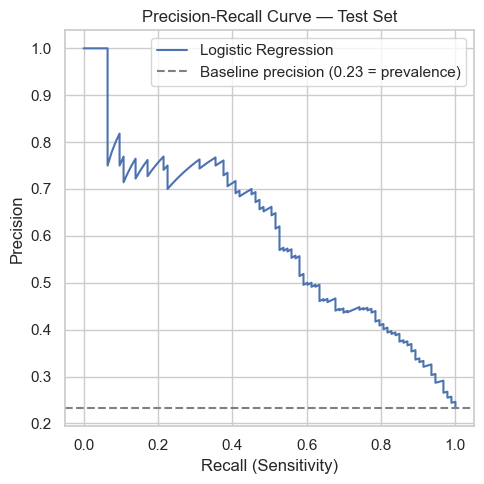

In [25]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, test_proba)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(recall_vals, precision_vals, label="Logistic Regression")
ax.axhline(y_test.mean(), color="gray", linestyle="--", label=f"Baseline precision ({y_test.mean():.2f} = prevalence)")
ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Test Set")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** The gray dashed line (precision = prevalence ≈ 20-25%) is the precision a *random* flagging strategy would achieve. Our curve sitting clearly above that line — especially at moderate-to-high recall — means the model is providing real discriminative value for care-management targeting, not just flagging patients at random.


## 12. Interpreting Coefficients as Odds Ratios

Logistic regression coefficients are on the **log-odds** scale. Exponentiating a coefficient (`exp(coef)`) gives an **odds ratio (OR)**:
- OR > 1 → the feature is associated with **higher** odds of 30-day readmission.
- OR < 1 → the feature is associated with **lower** odds.
- For standardized continuous features, the OR corresponds to a **one standard deviation** increase; for binary flags, it's the effect of the flag being "on."


In [26]:
or_table = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": final_model.coef_[0],
}).assign(odds_ratio=lambda d: np.exp(d["coefficient"])).sort_values("odds_ratio", ascending=False)

or_table.reset_index(drop=True)


,feature,coefficient,odds_ratio
0,comorbidity_count,0.587761,1.799953
1,prior_admissions_12mo,0.476441,1.610333
2,discharge_disposition_Home Health,0.365194,1.440794
3,no_followup_flag,0.305554,1.357376
4,heart_failure,0.299564,1.349270
5,sex_Male,0.284325,1.328865
6,bnp_was_missing,0.265746,1.304403
7,creatinine_was_missing,0.224549,1.251758
8,sodium_was_missing,0.223910,1.250959
9,elevated_bnp_flag,0.218748,1.244518


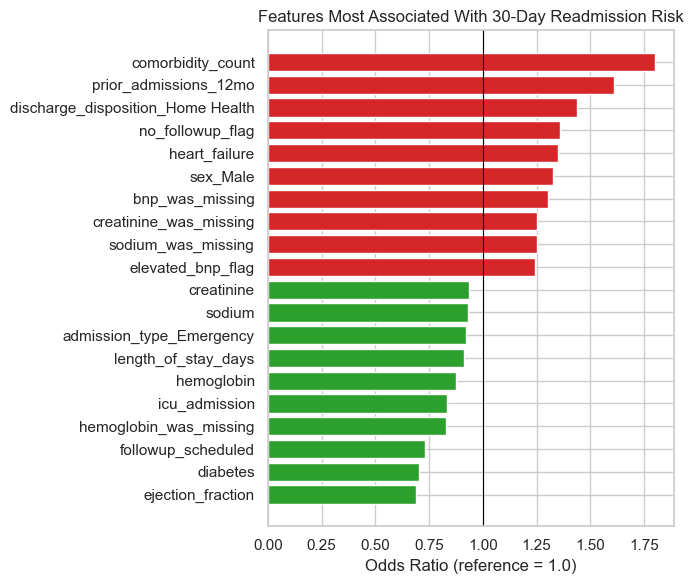

In [27]:
top_n = 10
plot_df = pd.concat([or_table.head(top_n), or_table.tail(top_n)]).drop_duplicates()
plot_df = plot_df.sort_values("odds_ratio")

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#2ca02c" if o < 1 else "#d62728" for o in plot_df["odds_ratio"]]
ax.barh(plot_df["feature"], plot_df["odds_ratio"], color=colors)
ax.axvline(1, color="black", linewidth=0.8)
ax.set_xlabel("Odds Ratio (reference = 1.0)")
ax.set_title("Features Most Associated With 30-Day Readmission Risk")
plt.tight_layout()
plt.show()


> 🩺 **Reading this clinically:** Features like `prior_admissions_12mo`, `high_utilizer_flag`, and `no_followup_flag` typically show up with **OR > 1** (increase readmission odds) — consistent with the readmission literature. `followup_scheduled` (its absence flagged separately) typically shows OR < 1 as a *protective* factor — and, notably, it's one of the few variables here that is **actionable at discharge**, unlike age or comorbidity count. Always inspect *your* run's actual table — exact ordering depends on the random seed/sample.


## 13. Summary

| Step | What we did | Why |
|---|---|---|
| EDA | Checked class balance (~20% readmitted) and a naive-baseline accuracy | Set expectations before trusting any accuracy number |
| Split | Stratified 60/20/20 train/val/test | Preserve class ratio across splits; avoid leakage |
| Imputation | Flag-then-fill, group medians (by heart failure / admission type) fit on train only | Clinically-informed, leakage-safe MAR handling |
| Feature Engineering | High-utilizer, polypharmacy, reduced-EF, elevated-BNP, no-follow-up flags | Encode established readmission-risk markers |
| Scaling | `StandardScaler` fit on train only | Comparable coefficients/odds ratios |
| CV | Stratified 5-fold, scored by ROC-AUC | Threshold-free, imbalance-robust model assessment |
| Imbalance Handling | Compared `class_weight="balanced"` vs. **SMOTE** (fit inside each CV fold via `imblearn.Pipeline`) vs. no adjustment | Two valid, largely interchangeable ways to counteract class imbalance during training; SMOTE must never be fit before splitting/CV to avoid leakage |
| Threshold Selection | Sensitivity/specificity/F1 vs. threshold table; Youden's J on validation | Translate a probability model into an operational decision rule |
| Final Evaluation | Test-set Accuracy, Sensitivity, Specificity, Precision, F1, ROC-AUC, PR curve | Honest, multi-angle generalization estimate |
| Interpretation | Odds ratios | Clinical plausibility check |

### Which metric to emphasize, in one sentence
**Use AUC-ROC to judge and compare *models* (threshold-independent); use Sensitivity/Recall as the primary metric to judge the *operating threshold* for a readmission-prevention program, because missing a true readmission (false negative) is clinically and financially costlier than an unnecessary outreach call (false positive) — but always check the resulting flagged caseload (`n_flagged`) against real staffing capacity, and report Specificity/Precision/F1 alongside so the trade-off being made is transparent.**

---

## Exercises for Students

1. **Capacity-constrained thresholding.** Suppose the hospital's transitional-care team can only manage 300 flagged patients per quarter. Using the threshold table in Section 9, pick the threshold that flags approximately that proportion of the test set, and report the resulting sensitivity/specificity. How different is it from the Youden-optimal threshold?
2. **Compare `class_weight="balanced"` vs. unweighted vs. SMOTE at a fixed, shared threshold.** Using the models already fit in Sections 8 and 10.1, evaluate all three at the *same* threshold (e.g., 0.5) rather than each at its own Youden threshold. How much does sensitivity change across strategies now? What does this tell you about how much of the earlier "difference" between class-weighting and SMOTE was really just due to picking different thresholds?
2b. **Try `SMOTE` variants.** Repeat the Section 7B comparison using `BorderlineSMOTE` or `ADASYN` (both in `imblearn.over_sampling`) in place of plain `SMOTE`. Do they change the CV ROC-AUC meaningfully for this dataset?
3. **Add a LACE-style composite score.** Construct a single composite risk score from Length of stay, Acuity (admission type), Comorbidity count, and prior Emergency visits (a simplified LACE-index proxy), and compare a model using only that composite vs. the full feature set. Does interpretability trade off against AUC?
4. **Calibration check.** Bin predicted probabilities into deciles and compare the *predicted* readmission rate to the *observed* readmission rate in each bin (a calibration plot). Is the model well-calibrated, or does it systematically over/under-predict risk in certain ranges?
5. **Try a tree-based model.** Fit a `RandomForestClassifier` or `GradientBoostingClassifier` on the same engineered features and compare ROC-AUC and the PR curve to logistic regression. Is the added complexity justified by the AUC gain, given that logistic regression's odds ratios are much easier to explain to a clinical audience?
